In [1]:
%load_ext autoreload

%autoreload 2


In [2]:
import plumed
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
import networkx as nx
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import MDAnalysis as mda
import pandas as pd
import os
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from deeptime.decomposition import TICA
from deeptime.covariance import KoopmanWeightingEstimator
from deeptime.clustering import MiniBatchKMeans
from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM,KoopmanReweightedMSM,BayesianMSM
from deeptime.plots import plot_implied_timescales
from deeptime.util.validation import implied_timescales
from deeptime.plots import plot_markov_model, Network, plot_flux
from copy import deepcopy
from numpy.random import multinomial
import copy
from collections import Counter
from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib as mpl
# import aplod

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# TICA functions         
def read_features(tica_lagtime,colvar):
    data = []
    traj = []
    for i in range(0,142):
        load = plumed.read_as_pandas(f'traj/{colvar}{i}')
        load = load.drop(columns=['time'])
        columns = list(load.columns.values)
        # Remove all dihedral angles, only keep sin/cos dihedrals 
        for column in columns:
            if column[2:5] == 'phi' or column[2:5] == 'psi' or column[2:5] == 'chi' or column[2:7] == 'omega':
                load = load.drop(columns=[column])
        if len(load) > 1.6*tica_lagtime:
            traj.append(load)
    
    # data is the time-series COLVAR in numpy.ndarrays format
    for i in range(len(traj)):
        numpy_data = traj[i].to_numpy(dtype='float32')
        data.append(numpy_data)
    return data
def run_TICA(data,lagtime,dim=None,var_cutoff=None):
    data_syn = data 
    tica = TICA(lagtime=lagtime,dim=dim,var_cutoff=var_cutoff, epsilon=1e-6)
    try:
        koopman_estimator = KoopmanWeightingEstimator(lagtime=lagtime)
        reweighting_model = koopman_estimator.fit(data_syn).fetch_model()
        tica = tica.fit(data_syn, weights=reweighting_model).fetch_model()
    except:
        print('Can\'t perform Koopman Reweighting TICA, try normal TICA')
        tica = tica.fit(data_syn).fetch_model()
    tica_output = []
    for i in data:
        tica_output.append(tica.transform(i))
    tica_output_concat = np.concatenate(tica_output)
    return tica,tica_output,tica_output_concat
def evaluate_its(assignments,lagtimes,n_its,round):
    models = []
    assignments_for_its = copy.deepcopy(assignments)
    for lagtime in lagtimes:
        counts = TransitionCountEstimator(lagtime=lagtime, count_mode='sliding').fit_fetch(assignments_for_its)
        models.append(MaximumLikelihoodMSM().fit_fetch(counts))
    its_data = implied_timescales(models)
    
    # Get the maximum number of available timescales
    max_available_its = its_data.max_n_processes
    n_its_plot = min(n_its, max_available_its)
    fig, ax = plt.subplots(1, 1)
    plot_implied_timescales(its_data, n_its=n_its_plot, ax=ax)
    ax.set_yscale('log')
    ax.set_title('Implied timescales')
    ax.set_xlabel('lag time (steps)')
    ax.set_ylabel('timescale (steps)')
    plt.savefig(f'./MSM/figures/its-round{round}.pdf',dpi=600)
    return assignments

def evaluate_tica_its(data,tica_its_lagtimes,dim,var_cutoff,koopman,n_its,round):
    tica_models = []
    for lag in tica_its_lagtimes:
        tica = run_TICA(data,lag,dim,var_cutoff)[0]
        tica_models.append(tica)
    its_data = implied_timescales(tica_models)
    fig, ax = plt.subplots(1, 1)
    plot_implied_timescales(its_data, n_its=n_its, ax=ax)
    ax.set_yscale('log')
    ax.set_title('Implied timescales')
    ax.set_xlabel('lag time (steps)')
    ax.set_ylabel('timescale (steps)')
    plt.savefig(f'./MSM/figures/tica-its-round{round}.pdf',dpi=600)
    return None
   
def calculate_nmicro(data_concat):
    # Heuristic approach to determine cluster number from htmd 
    # https://github.com/Acellera/htmd/blob/master/htmd/adaptive/adaptivebandit.py
    n_microstates = int(max(100, np.round(0.6 * np.log10(data_concat.shape[0] / 1000) * 1000 + 50)))
    return n_microstates
    
def run_kmeans(tica_output,tica_output_concat,n_microstates,n_jobs):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=n_microstates,batch_size=10000,max_iter=100,init_strategy='kmeans++',n_jobs=n_jobs)
    microstates = minibatch_kmeans.fit(tica_output_concat).fetch_model()
    cluster_centers = microstates.cluster_centers
    # assignments_concat is the microstate assignment in shape (traj_idx*no_frames,)
    # assignments is the microstate assignment in shape (traj_idx,no_frames)
    assignments = []
    for i in tica_output:
        assignments.append(microstates.transform(i))
    assignments_concat = np.concatenate(assignments)

    return assignments, cluster_centers
    
def build_MSM(msm_lagtime,assignments):
    assignments_syn = list(assignments)
    counts = TransitionCountEstimator(lagtime=msm_lagtime, count_mode='sliding').fit_fetch(assignments_syn)
    try:
        msm = KoopmanReweightedMSM().fit_fetch(counts)
    except Exception as e:
        print('Cannot perform Koopman Reweighting MSM, falling back to standard MSM')
        msm = MaximumLikelihoodMSM().fit_fetch(counts)
    return counts,msm
def build_bMSM(msm_lagtime,assignments):
    assignments_syn = list(assignments)
    counts = TransitionCountEstimator(lagtime=msm_lagtime, count_mode='effective').fit_fetch(assignments_syn)
    msm = BayesianMSM(lagtime=msm_lagtime, n_samples=100).fit_fetch(counts.submodel_largest())
    return counts,msm
def run_PCCA(msm,n_metastable_sets):
    pcca = msm.pcca(n_metastable_sets=n_metastable_sets)
    return pcca

### Adaptive seeding functions
def fix_disconnected(counts,n_microstates,msm,pcca,n_metastable_sets):
    ### Locate the connected and disconnected sets:
    sets = counts.connected_sets(connectivity_threshold=0,directed=True,sort_by_population=True)
    disconnected_sets = sets[1:]
    n_macro_disconnected = len(disconnected_sets)
    disconnected_dict = {}
    for i in range(n_macro_disconnected):
        macro_label = n_metastable_sets + i
        for j in disconnected_sets[i]:
            disconnected_dict[j] = macro_label

    pcca_assignments = np.zeros(n_microstates,dtype=int)
    stationary_distribution = np.zeros(n_microstates,)

    connected_count = 0
    for i in range(n_microstates):
        if i in disconnected_dict.keys():
            pcca_assignments[i] = disconnected_dict[i]
            stationary_distribution[i] = 0
        else:
            pcca_assignments[i] = pcca.assignments[connected_count]
            stationary_distribution[i] = msm.stationary_distribution[connected_count]
            connected_count += 1
        
    return n_macro_disconnected,pcca_assignments,stationary_distribution
    
#maybe it is not correct    
def count_macro(seed_num,pcca_assignments,assignments_concat):
    # Obtain macrostate assignment to original time-series data
    macro_assignments = dict(enumerate(pcca_assignments))
    macro_timeseries = np.vectorize(macro_assignments.get)(assignments_concat)
    # Macrostate seeding
    unique_macro, counts_macro = np.unique(macro_timeseries, return_counts=True)
    prob_macro = (1 / counts_macro) / np.sum(1 / counts_macro)
    macrostate_seed = multinomial(seed_num,prob_macro)

    # Microstate seeding
    # First count the occurences of all microstates
    unique_micro, counts_micro = np.unique(assignments_concat, return_counts=True)
    seed_idx = []
    counts_micro_i_log = {}
    for macro_i, n_sample in enumerate(macrostate_seed):
        # locate the index of microstates not assigned to current selected macrostates
        not_macro_idx = np.where(pcca_assignments != np.unique(pcca_assignments)[macro_i])
        # let all entries corresponding to not_macro_idx = 0, therefore ignore them during selection
        counts_micro_i = deepcopy(counts_micro)
        counts_micro_i[not_macro_idx] = 0
        # let 1/0 = 0
        inverse_counts = np.where(counts_micro_i==0, 0, 1/counts_micro_i)
        prob_micro_i = inverse_counts / np.sum(inverse_counts)
        microstate_seed = multinomial(n_sample,prob_micro_i)
        # Record selection statistics for visualization
        if n_sample != 0:
            macro_idx_log = unique_macro[macro_i] 
            counts_micro_i_log[macro_idx_log] = [counts_micro_i,microstate_seed]
        for micro_i, n_sample in enumerate(microstate_seed):
            seed_idx = seed_idx + n_sample * [micro_i]
   
    return seed_idx,macro_timeseries
def CKtest(msm_lagtime,k, n_space, n_metastable_sets, assignments,msm):
    ck_lagtimes = np.linspace(msm_lagtime,k*msm_lagtime,n_space,dtype=int)
    models = []
    for ck_lagtime in ck_lagtimes:
        counts = TransitionCountEstimator(lagtime=ck_lagtime,count_mode='sliding').fit_fetch(assignments)
        model = MaximumLikelihoodMSM().fit_fetch(counts)
        models.append(model)
    ck_test = msm.ck_test(models,n_metastable_sets=n_metastable_sets)
    return ck_test 
def BayesianMSM_CKtest(msm_lagtime,k, n_space, n_metastable_sets, assignments,bmsm):
    ck_lagtimes = np.linspace(msm_lagtime,k*msm_lagtime,n_space,dtype=int)
    models = []
    for ck_lagtime in ck_lagtimes:
        counts = TransitionCountEstimator(lagtime=ck_lagtime,count_mode='effective').fit_fetch(assignments)
        model = BayesianMSM(lagtime=ck_lagtime, n_samples=100).fit_fetch(counts.submodel_largest())
        models.append(model)
    ck_test = bmsm.ck_test(models,n_metastable_sets=n_metastable_sets)
    return ck_test 
def plot_msmeigenvalues(msm,round):
    eigenvalues = msm.eigenvalues()
    plt.figure(figsize=(8,6))
    plt.plot(np.real(eigenvalues),'bo',label='Eigenvalues')
    plt.axhline(y=0.369,color='gray',linestyle='--')
    plt.title('MSM Eigenvalues')
    plt.xlabel('Index')
    plt.ylabel('Eigenvalue')
    plt.savefig(f'./MSM/figures/MSMEigenvalue{round}.png',dpi=600)
    msm_dim = len([num for num in eigenvalues if abs(num) > 0.369])
    print(f'{msm_dim} eigenvalues over 0.369')
    return msm_dim
def plot_ticaeigenvalues(tica,round):
    eigenvalues = tica.singular_values
    plt.figure(figsize=(8,6))
    plt.plot(np.real(eigenvalues),'bo',label='Eigenvalues')
    plt.axhline(y=0.369,color='gray',linestyle='--')
    plt.title('TICA Eigenvalues')
    plt.xlabel('Index')
    plt.ylabel('Eigenvalue')
    plt.savefig(f'./MSM/figures/TICAEigenvalue{round}.png',dpi=600)
    tica_dim = len([num for num in eigenvalues if num > 0.369])
    print(f'{tica_dim} eigenvalues over 0.369')
    return tica_dim



In [ ]:
tica_lagtime = 20
dim = None
var_cutoff = 0.90
koopman = True
runtICA_njobs = 36

# Implied time scale evaluation
its_lagtimes = [20,50,100,150,200,250,300,400,500]
tica_its_lagtimes = [5,10,20,35,50,100,150]
n_its = 5

# Markov State Model parameters
msm_lagtime = 200
# PCCA parameters
n_metastable_sets = 4
seed_num = 25
assignments = []
seed_idx = []

In [7]:
#Perform tICA
data= read_features(tica_lagtime,'COLVAR_tica')

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


In [8]:
tica_output = data
tica_output_concat = np.concatenate(tica_output)

In [42]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt


def knn_densitypeak(X, k=1000,dc = 1,method='exp'):
    """
    KNN-densitypeak clustering core computation.
    
    Parameters
    ----------
    X : array-like, shape [n_samples, n_features]
        Input data.
    k : int
        Number of neighbors for local comparison.
        
    Returns
    -------
    rho : local density values
    delta : distance to nearest higher-density neighbor (in kNN)
    nneigh : index of nearest higher-density neighbor
    """
    n = X.shape[0]
    
    # Step 1: compute kNN
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X) 
    distances, indices = nbrs.kneighbors(X) # distance [n_samples, k+1] indices [n_samples, k+1]
    
    # remove the point itself (distance=0, index itself)
    distances = distances[:, 1:] # shape [n_samples, k]
    indices = indices[:, 1:] # shape [n_samples, k]
    
    # Step 2: local density ρ(i) using kNN distances
    # typical DP algorithm uses cutoff or gaussian kernel;
    # here we simply use inverse-distance density
    if method == 'exp':
        rho = np.sum(np.exp(-(distances/dc)**2), axis=1) # shape [n_samples,]
    else:
        mask = distances < dc
        rho = np.sum(mask, axis=1) # shape [n_samples,]
    
    # Step 3: compute δ(i)
    delta = np.zeros(n) # [n_samples,]
    nneigh = np.zeros(n, dtype=int) # [n_samples,]

    # sort by descending rho
    order = np.argsort(-rho) # [n_samples,]

    # For highest-density point: delta = max distance to any kNN (local)
    delta[order[0]] = np.max(distances[order[0]])
    nneigh[order[0]] = order[0]  # no higher-density neighbor

    # For all other points
    for idx in order[1:]:
        # candidates = neighbors with higher density
        neighbor_idxs = indices[idx] # shape [k,]
        higher_mask = rho[neighbor_idxs] > rho[idx]

        if np.any(higher_mask):
            # choose nearest among them
            candidate_neighbors = neighbor_idxs[higher_mask]
            candidate_distances = np.linalg.norm(
                X[candidate_neighbors] - X[idx], axis=1
            )
            j = candidate_neighbors[np.argmin(candidate_distances)]
            delta[idx] = np.min(candidate_distances)
            nneigh[idx] = j
        else:
            # no higher-density in kNN → use max kNN distance
            delta[idx] = np.max(distances[idx])
            nneigh[idx] = idx  # no higher-density neighbor
    gamma = rho * delta
    return rho, delta, nneigh , gamma
def assignment_labels(X,rho,gamma, nneigh, num_centers):
    order = np.argsort(-rho)
    n = np.shape(rho)[0]
    # choose top num_centers
    center_indices = np.argsort(-gamma)[:num_centers]
    center_indices = list(center_indices)

    # ========== Step 5: assign labels ==========
    labels = -np.ones(n, dtype=int)

    # assign center labels
    for i, c in enumerate(center_indices):
        labels[c] = i
    # assign others following density order
    for idx in order:
        if labels[idx] == -1:            
            if nneigh[idx] == idx:
                dist_to_centers = np.linalg.norm(X[idx] - X[center_indices], axis=1)
                labels[idx] = np.argmin(dist_to_centers)
            else:
                labels[idx] = labels[nneigh[idx]]  # inherit cluster of nearest higher-density neighbor
    return center_indices, labels

In [121]:
rho, delta, nneigh,gamma = knn_densitypeak(tica_output_concat,k=10000,dc=2,method='dis')

In [122]:
class_num = 200
centers_idx, assignments_concat = assignment_labels(tica_output_concat, rho, gamma, nneigh, class_num)
assignments = []
start = 0
for i in range(len(tica_output)):
    end = start + tica_output[i].shape[0]
    assignments.append(np.array(assignments_concat[start:end]))
    start = end
assignments1 = list(assignments)

In [140]:
np.save('center_idx_final.npy', np.array(centers_idx, dtype=object))

In [9]:
centers_idx = np.load('center_idx_final.npy', allow_pickle=True)
centers_idx = list(centers_idx)

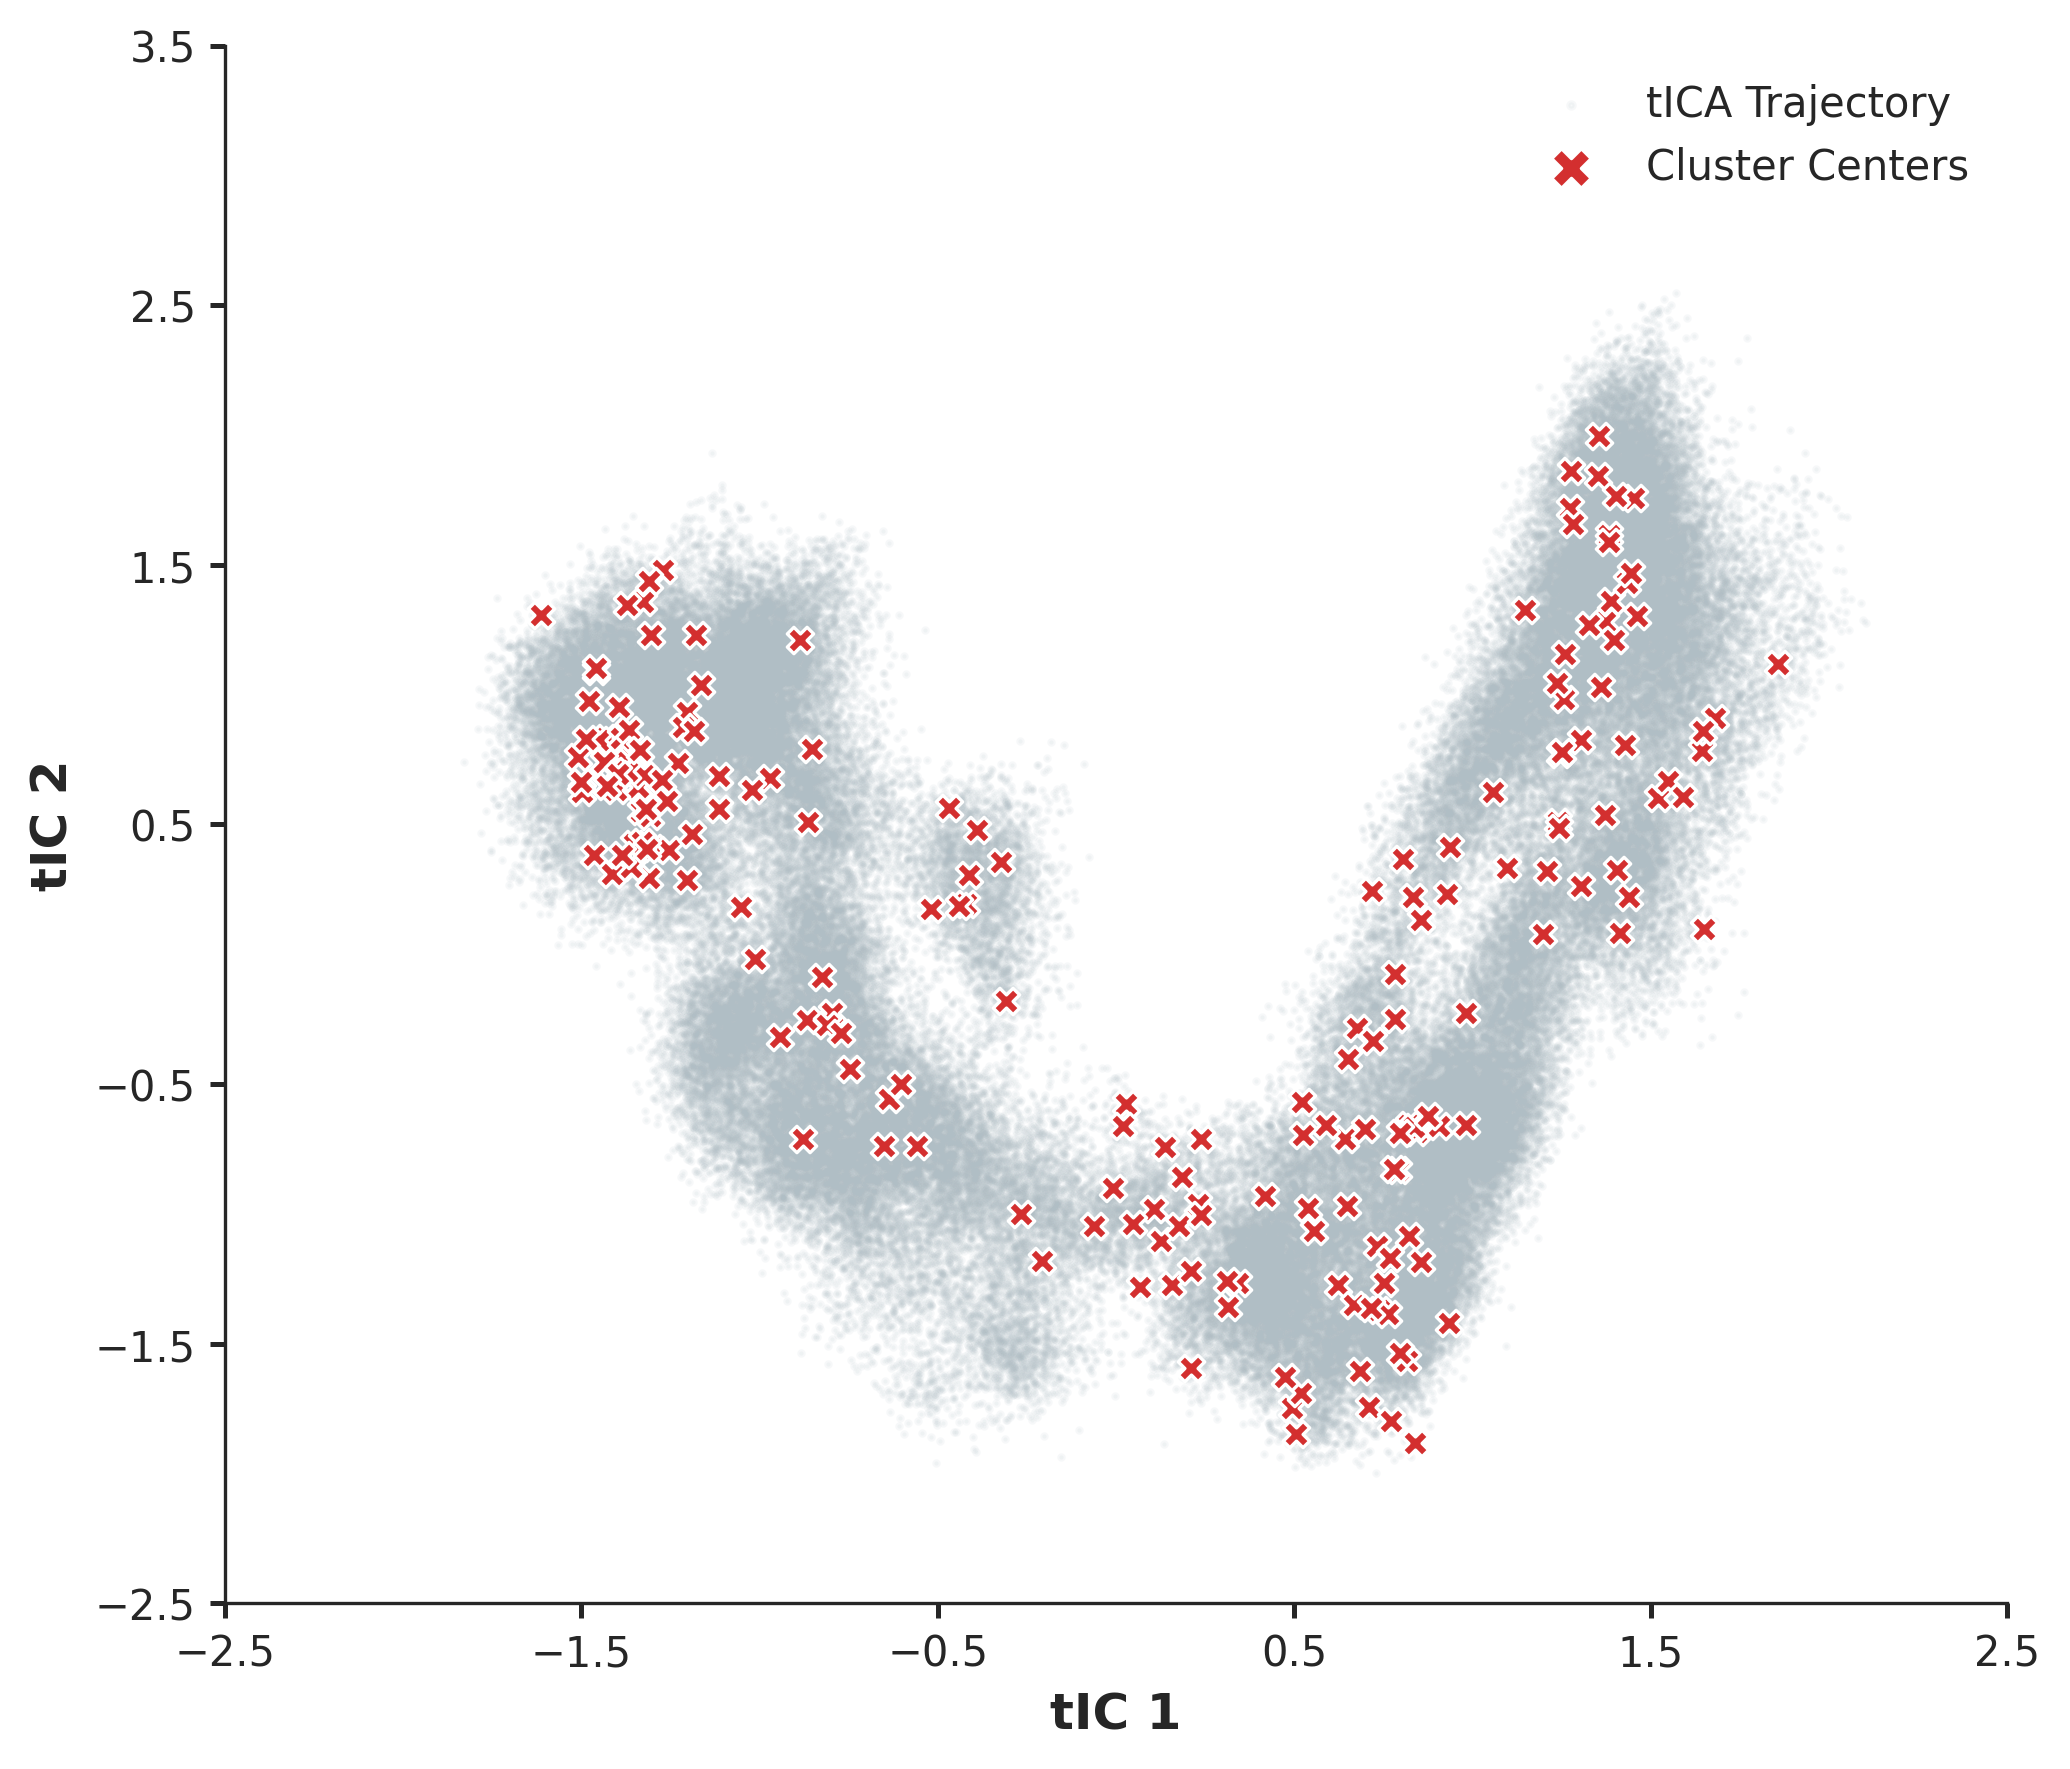

In [ ]:
centers = tica_output_concat[centers_idx]
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("ticks")
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

ax.scatter(tica_output_concat[:,0], tica_output_concat[:,1], 
           s=1, alpha=0.1, c='#B0BEC5', label='tICA Trajectory', rasterized=True)

ax.scatter(centers[:,0], centers[:,1], 
           s=40, c='#D32F2F', marker='X', edgecolor='white', 
           linewidth=0.8, label='Cluster Centers', zorder=5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

xmin, xmax = -2.5, 2.5
ymin, ymax = -2.5, 3.5

ax.set_xticks(np.arange(xmin, xmax + 0.5, 1))
ax.set_yticks(np.arange(ymin, ymax + 0.5, 1))
ax.tick_params(axis='both', labelsize=10, width=1.2)

ax.set_xlabel('tIC 1', fontsize=12, fontweight='bold')
ax.set_ylabel('tIC 2', fontsize=12, fontweight='bold')

ax.legend(loc='upper right', frameon=False, markerscale=1.5)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.savefig('SI_TICA_Centers.pdf', bbox_inches='tight')
plt.show()

In [141]:
matrix = np.array(assignments1, dtype=object)
np.save('assignment_knndp_final.npy', matrix)

In [10]:
assignments = np.load('assignment_knndp_final.npy', allow_pickle=True)
assignments1 = []
for i in range(assignments.shape[0]):
    assignments1.append(np.array(assignments[i],dtype=np.int32))
assignments_concat = np.concatenate(assignments1)

Skipping state set [193] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [183] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [167] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [64] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..


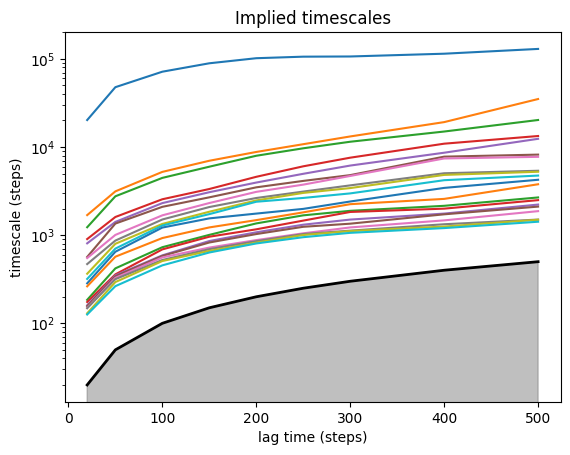

In [11]:
assignments = evaluate_its(assignments1,its_lagtimes,20,round)

In [15]:
counts,msm = build_MSM(msm_lagtime,assignments1)
msm.transition_matrix.shape

Cannot perform Koopman Reweighting MSM, falling back to standard MSM


(200, 200)

In [13]:
bcounts,bmsm = build_bMSM(msm_lagtime,assignments1)

35 eigenvalues over 0.369


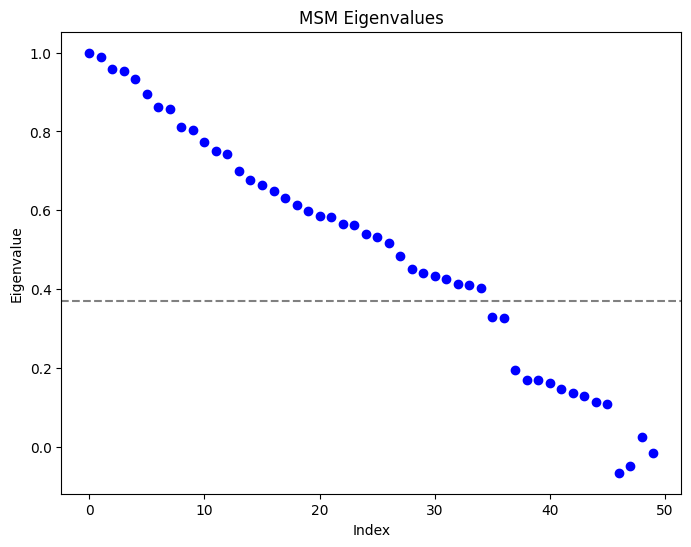

In [39]:
pcca_dim = plot_msmeigenvalues(msm,round)

/usr/local/lib/python3.10/dist-packages/deeptime/plots/chapman_kolmogorov.py:174: ComplexWarning: Your CKtest contains imaginary components which are ignored during plotting.
  warnings.warn("Your CKtest contains imaginary components which are ignored during plotting.",


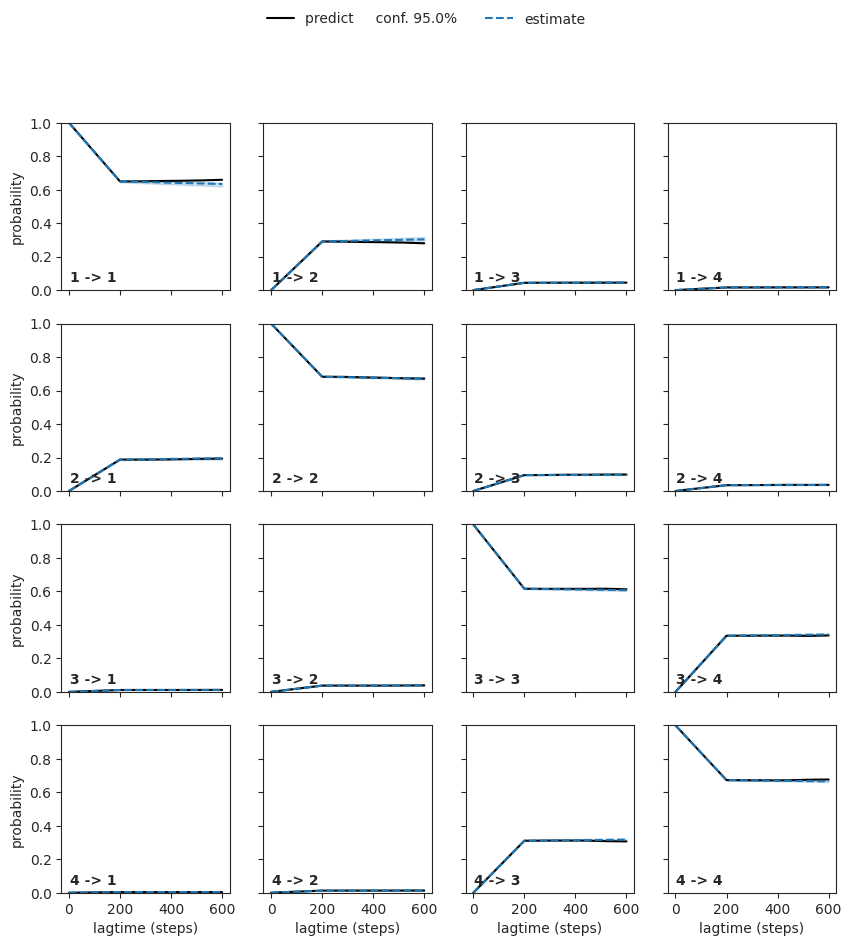

In [139]:
from deeptime.plots.chapman_kolmogorov import plot_ck_test
bck_test = BayesianMSM_CKtest(msm_lagtime,3, 6, 4, assignments1,bmsm)
grid = plot_ck_test(bck_test)
plt.savefig(f'./MSM/figures/CKtest.pdf',dpi=600)

In [ ]:
pcca = run_PCCA(msm,n_metastable_sets)
class_num = 200
n_macro_disconnected,pcca_assignments,stationary_distribution = fix_disconnected(counts,class_num,msm,pcca,n_metastable_sets)
seed_idx,macro_timeseries = count_macro(seed_num,pcca_assignments,assignments_concat)
for i in np.unique(pcca.assignments):
    print(f'Macrostate {i+1}: {pcca.coarse_grained_stationary_probability[i]:.4f} stationary distribution')

Macrostate 1: 0.0812 stationary distribution
Macrostate 2: 0.1136 stationary distribution
Macrostate 3: 0.4033 stationary distribution
Macrostate 4: 0.4019 stationary distribution


/tmp/ipykernel_4964/547244955.py:166: RuntimeWarning: divide by zero encountered in divide
  inverse_counts = np.where(counts_micro_i==0, 0, 1/counts_micro_i)


In [17]:
metastable_sets = []
for metastable in range(n_metastable_sets):
    metastable_set = []
    for i in range(len(pcca.assignments)):    
        if pcca.assignments[i] == metastable:
            metastable_set.append(i)
    metastable_sets.append(metastable_set)

In [131]:
def reactiveflux(bmsm, metastable_sets,msm_lagtime):
    macro_fluxes = []  # 存储每个样本的宏状态间通量矩阵
    n_macro = len(metastable_sets)
    # 2. 遍历贝叶斯样本进行计算
    for i, p_sample in enumerate(bmsm.samples):
        sample_macro_matrix = np.zeros((n_macro, n_macro))  # 存储该样本的宏状态间转移矩阵
        for i, state_A in enumerate(metastable_sets):
            for j, state_B in enumerate(metastable_sets):
                try:
                    flux = p_sample.reactive_flux(state_A, state_B)
                    sample_macro_matrix[i,j] = flux.total_flux
                except:
                    sample_macro_matrix[i,j] = 0
        macro_fluxes.append(sample_macro_matrix)

    macro_fluxes = np.array(macro_fluxes)  # 转为 NumPy 数组，形状 (n_samples, n_macro, n_macro)
    flux_mean = np.mean(macro_fluxes,axis=0)/msm_lagtime*1000000
    flux_std = np.std(macro_fluxes,axis=0)/msm_lagtime*1000000
    return flux_mean, flux_std
flux_mean, flux_std = reactiveflux(bmsm, metastable_sets, msm_lagtime)

In [19]:
def mfpt(bmsm, metastable_sets,msm_lagtime):
    macro_mfpts = []  # 存储每个样本的宏状态间通量矩阵
    n_macro = len(metastable_sets)
    # 2. 遍历贝叶斯样本进行计算
    for i, p_sample in enumerate(bmsm.samples):
        sample_macro_matrix = np.zeros((n_macro, n_macro))  # 存储该样本的宏状态间转移矩阵
        for i, state_A in enumerate(metastable_sets):
            for j, state_B in enumerate(metastable_sets):
                try:
                    sample_macro_matrix[i,j] = p_sample.mfpt(state_A, state_B)
                except:
                    sample_macro_matrix[i,j] = 0
        macro_mfpts.append(sample_macro_matrix)

    macro_mfpts = np.array(macro_mfpts)  # 转为 NumPy 数组，形状 (n_samples, n_macro, n_macro)
    mfpt_mean = np.mean(macro_mfpts,axis=0)*msm_lagtime/1000/1000
    mfpt_std = np.std(macro_mfpts,axis=0)*msm_lagtime/1000/1000
    return mfpt_mean, mfpt_std
mfpt_mean, mfpt_std = mfpt(bmsm, metastable_sets, msm_lagtime)

In [21]:
mfpt = np.zeros((n_metastable_sets, n_metastable_sets))
for i in range(n_metastable_sets):
    for j in range(n_metastable_sets):
        mfpt[i, j] = msm.mfpt(
            metastable_sets[i],
            metastable_sets[j])
from pandas import DataFrame
print('MFPT / ms:')
# DataFrame(np.round(mfpt, decimals=2), index=range(1, 6), columns=range(1, 6))
mfpt_ms = mfpt * msm_lagtime/1000/1000
print(DataFrame(np.round(mfpt_ms, decimals=2), index=range(1, n_metastable_sets+1), columns=range(1, n_metastable_sets+1)))

MFPT / ms:
       1       2      3      4
1   0.00   16.43  13.70  26.95
2   2.90    0.00  17.12  30.38
3  67.25  107.45   0.00   3.44
4  70.77  111.06   2.11   0.00


In [22]:
flux_matrix = np.zeros((len(metastable_sets), len(metastable_sets)))  # 存储该样本的宏状态间转移矩阵
for i, state_A in enumerate(metastable_sets):
    for j, state_B in enumerate(metastable_sets):
        try:
            flux = msm.reactive_flux(state_A, state_B)
            flux_matrix[i,j] = flux.total_flux
        except:
            flux_matrix[i,j] = 0
flux_ms = flux_matrix/msm_lagtime*1000000
print('Reactive Flux / /ms:')
print(DataFrame(np.round(flux_ms, decimals=2), index=range(1, n_metastable_sets+1), columns=range(1, n_metastable_sets+1)))

Reactive Flux / /ms:
       1      2      3      4
1   0.00  17.07   5.14   2.21
2  17.07   0.00   2.33   1.44
3   5.14   2.33   0.00  61.50
4   2.21   1.44  61.50   0.00


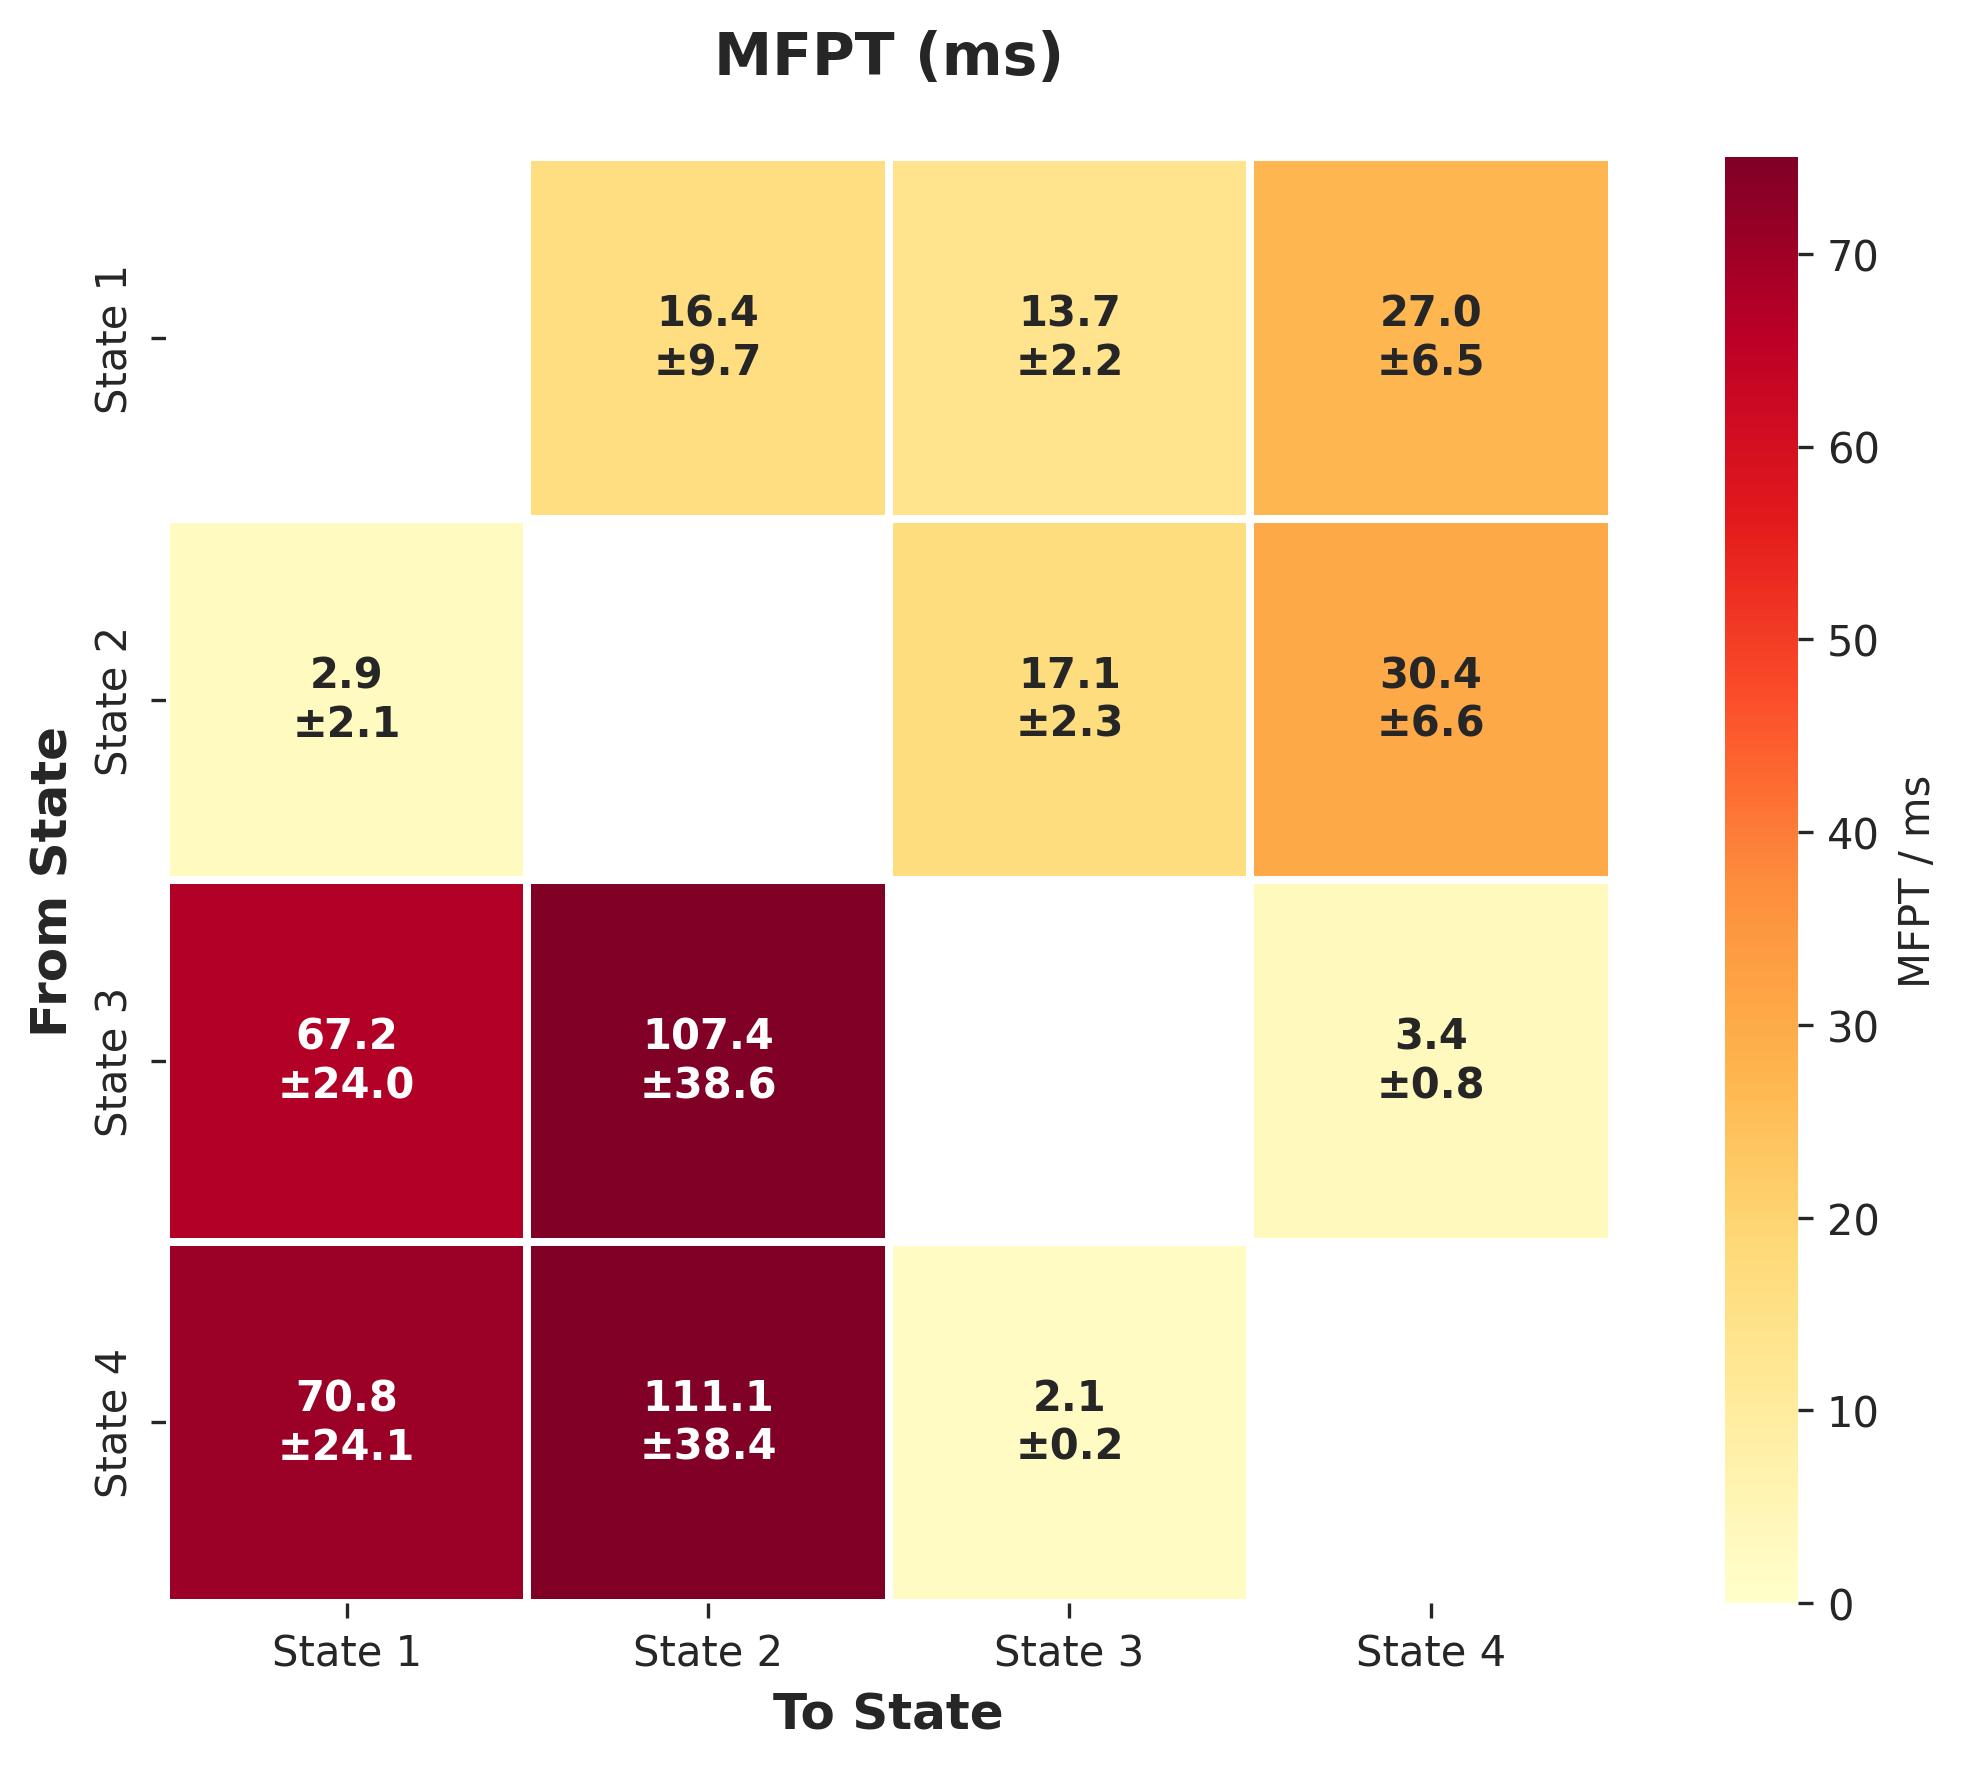

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_mfpt_matrix(data_matrix, data_std, labels=None, title='MFPT Matrix (ms)', save_name='mfpt_heatmap.pdf'):
    n = len(data_matrix)
    if labels is None:
        labels = [f'State {i+1}' for i in range(n)]
    
    # 1. 核心修改：生成带有 ± std 的文本标注矩阵
    # 使用 list comprehension 构建一个与数据维度相同的字符串数组
    annot_labels = []
    for i in range(n):
        row = []
        for j in range(n):
            if i == j: # 对角线通常为 0，可以选择留空或只写 0
                row.append("")
            else:
                # 格式：Mean ± Std
                row.append(f"{data_matrix[i, j]:.1f}\n±{data_std[i, j]:.1f}")
        annot_labels.append(row)
    
    annot_labels = np.array(annot_labels)

    df = pd.DataFrame(data_matrix, index=labels, columns=labels)
    
    # 根据内容调整画布，因为多了 STD，格子需要更高一点
    fig_size = (max(8, n*1.5), max(6, n*1.2))
    fig, ax = plt.subplots(figsize=fig_size, dpi=300)

    mask = np.eye(n)
    custom_vmax = 75.0  
    custom_vmin = 0.0

    # 2. 关键参数：annot=annot_labels (传入自定义文本) 和 fmt="" (关闭自动格式化)
    sns.heatmap(df, 
                annot=annot_labels,      # <--- 使用我们构建的字符串矩阵
                fmt="",                  # <--- 必须设为空，否则会报错
                cmap="YlOrRd", 
                linewidths=1.5, 
                linecolor='white',
                mask=mask,               
                cbar_kws={'label': 'MFPT / ms'},
                annot_kws={"size": 10, "weight": "bold"}, # 字体调小一点点以适应两行文字
                vmin=custom_vmin,        
                vmax=custom_vmax,        
                square=True,             
                ax=ax)

    ax.set_title(title, fontsize=14, pad=20, fontweight='bold')
    ax.set_xlabel('To State', fontsize=12, fontweight='bold')
    ax.set_ylabel('From State', fontsize=12, fontweight='bold')
    
    for _, spine in ax.spines.items():
        spine.set_visible(False)

    plt.tight_layout()
    plt.savefig(save_name, bbox_inches='tight', transparent=True)
    plt.show()

# 调用示例 (假设 mfpt_ms 和 mfpt_std 是 numpy 数组)
plot_mfpt_matrix(mfpt_ms, mfpt_std, title='MFPT (ms)', save_name='MFPT_Heatmap.pdf')

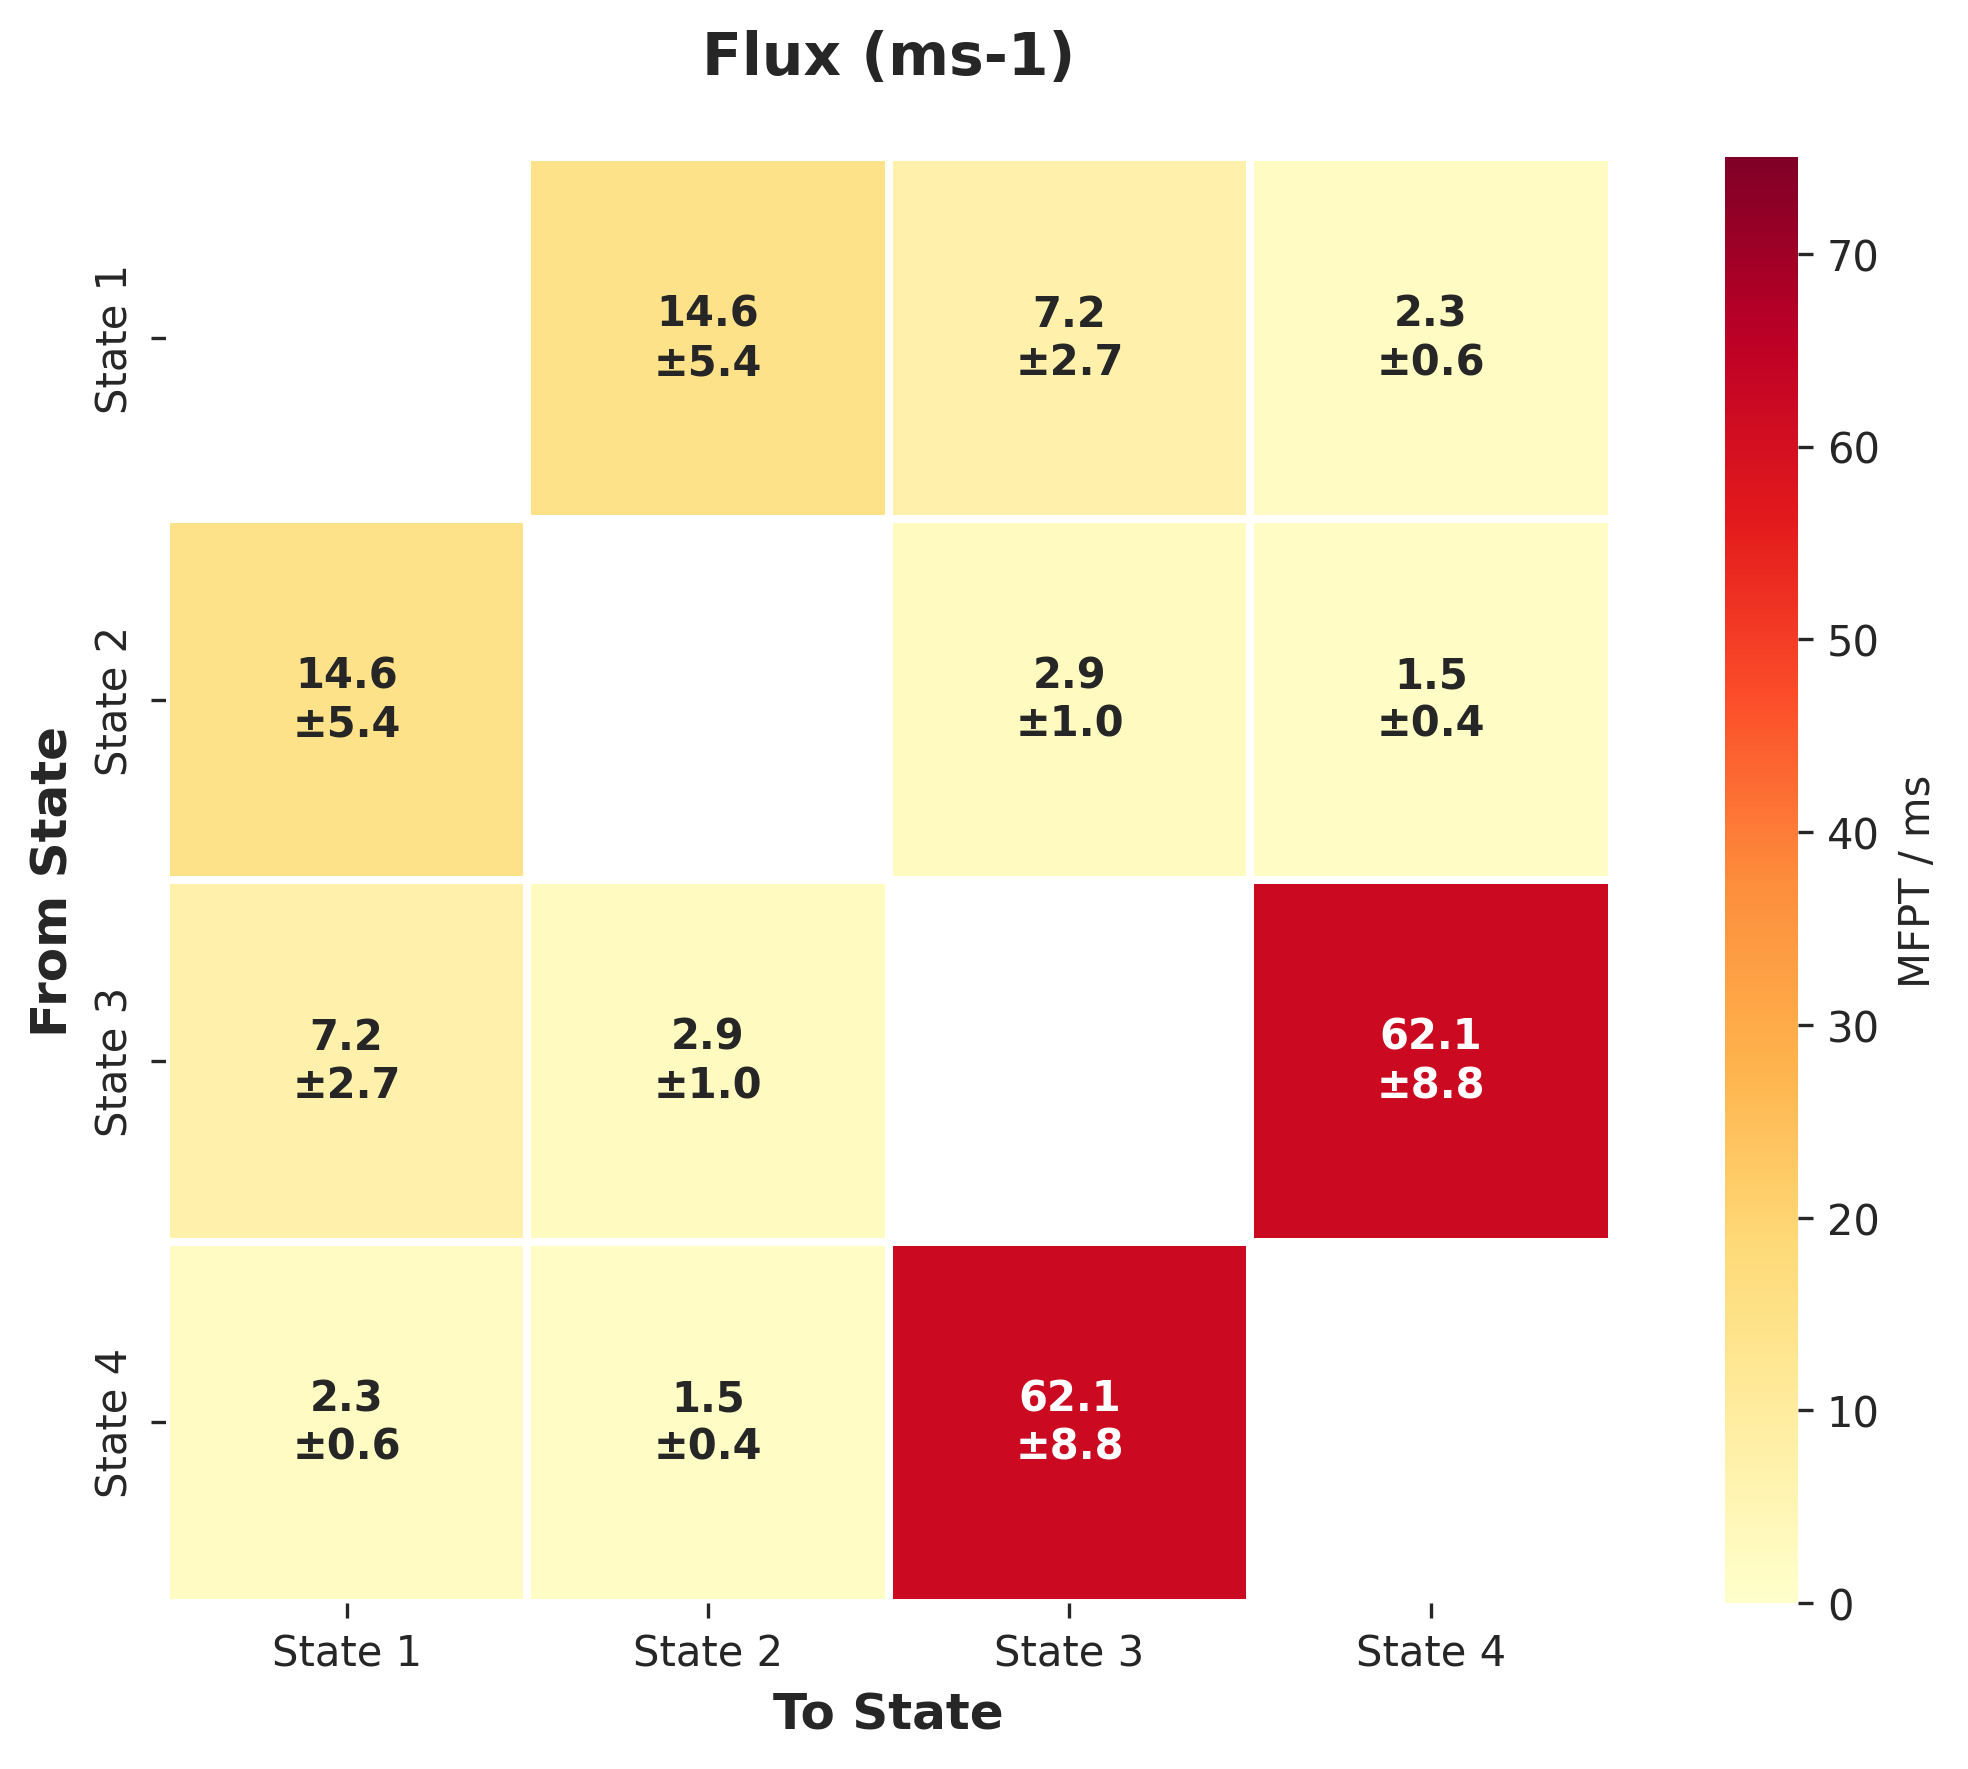

In [137]:
plot_mfpt_matrix(flux_mean,flux_std, title='Flux (ms-1)', save_name='Flux_Heatmap.pdf')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
from deeptime.plots import plot_energy2d
from deeptime.util import energy2d
import numpy as np

def plot_pcca_graph(traj_all, traj_weights,  
                    c_centers, mfpt_matrix, flux_matrix,pcca_assignment, stat_dist,pcca_population, 
                    fes_cmap='nipy_spectral', dim_1 = 0, dim_2 = 1, 
                    c_centers_s=50, c_centers_marker='.', c_centers_a=0.5, 
                    pcca_cmap='gist_rainbow', c_edgecolor='black', linewidth=1, 
                    g_alpha=0.8, connectionstyle='Angle3',
                    cryo_EM_apo=None,cryo_EM_bound=None,cryo_EM_marker='X',cryo_EM_s=100,cryo_EM_a=1,
                    savedir=None,fes=True,state=True,mfpt=True,flux=True,microstate=True,macrostate=True):
    
    """
    Plots a PCCA+ graph on top of a 2D free energy surface (FES).

    Parameters
    ----------
    traj_all : np.ndarray
        Array of shape (n_samples, n_dimensions) containing (tica) trajectory data.
    traj_weights : np.ndarray
        Array of shape (n_samples,) containing the weights for each trajectory point. Used in FES calculation.
    c_centers : np.ndarray
        Array of shape (n_clusters, n_dimensions) containing the cluster centers. Used to determine node positions.
    mfpt_matrix : np.ndarray
        MFPT matrix between PCCA+ macrostates. Used to determine edge weights.
    flux_matrix : np.ndarray
        Flux matrix between PCCA+ macrostates. Used to determine edge weights.
    pcca_assignment : np.ndarray
        Array of shape (n_clusters,) containing the PCCA+ assignment for each cluster. Used to group clusters into macrostates.
    stat_dist : np.ndarray
        Array of shape (n_clusters,) containing the stationary distribution of each cluster. Used to scale node sizes.
    """

    n_states = len(np.unique(pcca_assignment))
    colours = [cm.get_cmap(pcca_cmap)(i/(5)) for i in range(6)]
    colours = [
          "#B8A1E3",
          "#00F56A",
    "#0D11F0",  # mint-teal
    "#F4CFB6",  # apricot
    ]   
    v_min = 0
    v_max = 30  
    n_levels = 16 

    custom_levels = np.linspace(v_min, v_max, n_levels)
        # Compute the centeroids of pcca macrostates 
    # Using the microstate centers weighted by the stationary probability
    macrostate_centroid = []
    for i in range(n_states):
        macrostate_cluster_centers = c_centers[pcca_assignment == i, :]
        macrostate_cluster_weights = stat_dist[pcca_assignment == i]
        weighted_centroid = np.average(macrostate_cluster_centers, axis=0, weights=macrostate_cluster_weights)
        macrostate_centroid.append(weighted_centroid)
    pos = {i:(macrostate_centroid[i][dim_1], macrostate_centroid[i][dim_2]) for i in range(n_states)}

    # Node sizes are scaled by the stationary probability of the macrostate
    cg_stationary_dist = [sum(stat_dist[pcca_assignment == i]) for i in range(n_states)]
    node_sizes = pcca_population*10000

    node_ln_widths = np.cbrt(node_sizes)*0.1

    fig, ax = plt.subplots(figsize=(11, 10))
    if fes == True:   
        ax, contour, cbar = plot_energy2d(energy2d(traj_all[:, dim_1], traj_all[:, dim_2], weights=traj_weights,kbt=8.3145*310/1000), ax=ax, contourf_kws=dict(cmap=fes_cmap,vmin=v_min,vmax=v_max,level=n_levels),levels=custom_levels)

        ax.set_xlabel(f'tIC {dim_1+1}', fontsize=14)
        ax.set_ylabel(f'tIC {dim_2+1}', fontsize=14)
        cbar.ax.set_ylabel('Free energy (kJ/mol)', fontsize=14)

        # Add nodes and edges to the graph

    if state == True:
        if microstate == True:
            for i in range(n_states):
                    ax.scatter(c_centers[pcca_assignment == i, dim_1], c_centers[pcca_assignment == i, dim_2], 
                            s=c_centers_s, c=colours[i], marker=c_centers_marker, alpha=c_centers_a, 
                            edgecolor=c_edgecolor, linewidth=linewidth)
        if macrostate == True:
            G = nx.DiGraph()
            for i in range(n_states):
                G.add_node(i)
                if mfpt:
                    for j in range(n_states):
                        if mfpt_matrix[i, j] > 0 and mfpt_matrix[i, j] < np.inf:
                            if (i != j) and (mfpt_matrix[i, j] < 3000000):  # Ignore very large MFPTs
                                G.add_edge(i, j, weight=np.log2(max(mfpt_matrix.flatten()) / mfpt_matrix[i, j]))
                if flux:
                    for j in range(n_states):
                        if flux_matrix[i, j] > 0:
                            G.add_edge(i, j, weight=np.log2(flux_matrix[i, j] / max(flux_matrix.flatten())))
            edge_widths = [edge[2]['weight'] for edge in G.edges(data=True)]
            if mfpt or flux:
                nx.draw(G, pos, 
                node_size=node_sizes[[node[0] for node in G.nodes(data=True)]],
                node_color=[colours[node[0]] for node in list(G.nodes(data=True))], 
                edgecolors='black', linewidths=node_ln_widths[[node[0] for node in G.nodes(data=True)]], 
                alpha=g_alpha, 
                edge_color = [colours[edge[0]] for edge in G.edges(data=True)], 
                width=edge_widths, arrows=True, connectionstyle=connectionstyle,
                ax=ax)
            else:
                nx.draw_networkx_nodes(G, pos, 
                        node_size=node_sizes[[node[0] for node in G.nodes(data=True)]],
                        node_color=[colours[node[0]] for node in list(G.nodes(data=True))], 
                        edgecolors='black', 
                        node_shape='*',
                        linewidths=node_ln_widths[[node[0] for node in G.nodes(data=True)]], 
                        alpha=g_alpha,
                        ax=ax)


    if cryo_EM_apo is not None:
        ax.scatter(cryo_EM_apo[0], cryo_EM_apo[1], s=cryo_EM_s, c='black', marker=cryo_EM_marker, alpha=cryo_EM_a, label='Apo Cryo-EM')
    if cryo_EM_bound is not None:
        ax.scatter(cryo_EM_bound[0], cryo_EM_bound[1], s=cryo_EM_s, c='red', marker=cryo_EM_marker, alpha=cryo_EM_a, label='Bound Cryo-EM')
    plt.tight_layout(pad=2.0)
    if savedir is not None:
        plt.savefig(savedir, transparent=True, bbox_inches='tight', dpi=300)
    plt.show()

    return pos


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
/tmp/ipykernel_4964/1885031082.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = [cm.get_cmap(pcca_cmap)(i/(5)) for i in range(6)]
/usr/local/lib/python3.10/dist-packages/deeptime/plots/energy.py:83: UserWarning: The following kwargs were not used by contour: 'level'
  mappable = ax.contourf(energies.x_meshgrid, energies.y_meshgrid, energies.energies, levels=levels, **contourf_kws)


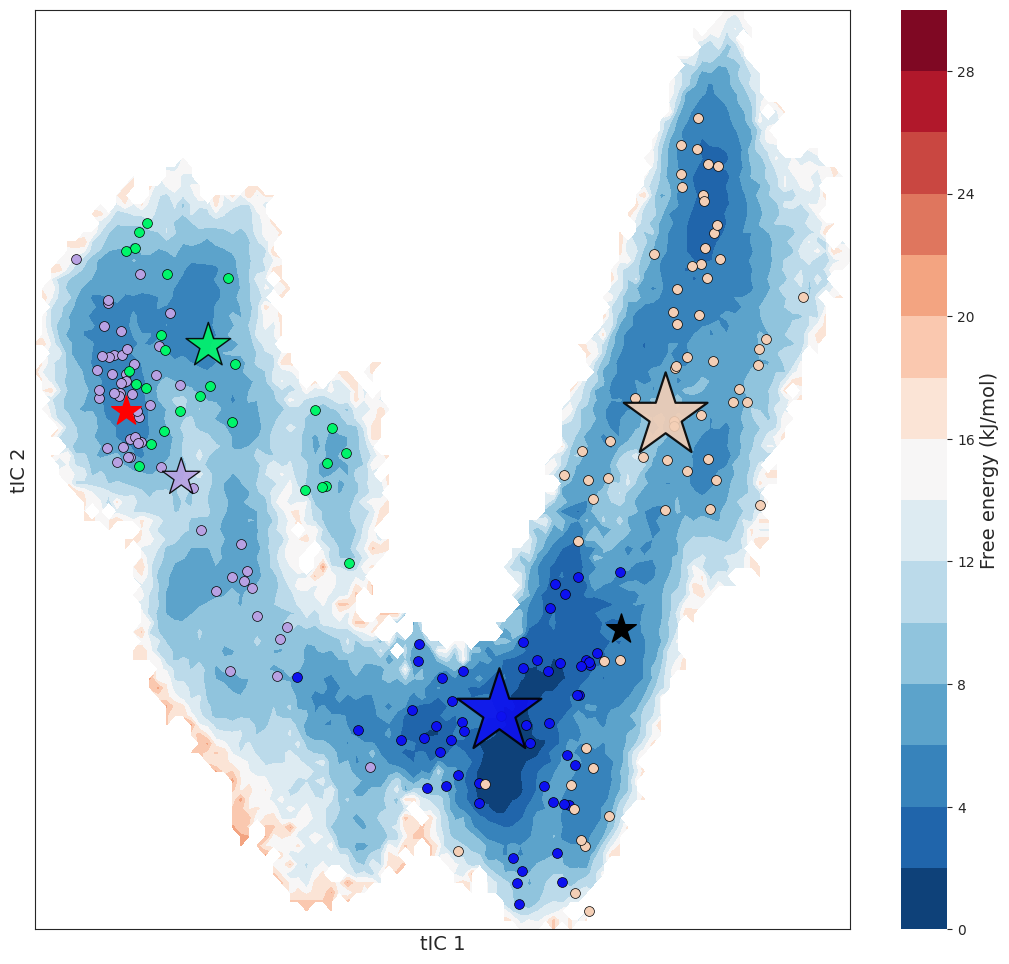

In [ ]:
c_centers = centers[msm.count_model.state_symbols]

connected_sets = counts.connected_sets(connectivity_threshold=0,directed=True,sort_by_population=True)[0]
mask = np.isin(np.array(assignments_concat), connected_sets)  
valid_idx = np.where(mask)[0]

dtrajs_valid = np.array(assignments_concat)[valid_idx]
tica0_valid = np.array(tica_output_concat[:,0][valid_idx]).astype(np.float32)
tica1_valid = np.array(tica_output_concat[:,1][valid_idx]).astype(np.float32)
unique_vals = np.unique(dtrajs_valid) 
value_to_rank = {val: i for i, val in enumerate(unique_vals)}

dtrajs_valid_dense = np.array([value_to_rank[val] for val in dtrajs_valid])
pi_valid = msm.stationary_distribution[dtrajs_valid_dense]
_,num_frame_per_microstate = np.unique(assignments_concat, return_counts=True)
p_valid = num_frame_per_microstate[dtrajs_valid]
wi_valid = pi_valid/p_valid
nan_inf_mask0 = np.isnan(tica0_valid) | np.isinf(tica0_valid)
nan_inf_mask1 = np.isnan(tica1_valid) | np.isinf(tica1_valid)
combined_mask = ~(nan_inf_mask0 | nan_inf_mask1)
tica0_valid_clean = tica0_valid[combined_mask]
tica1_valid_clean = tica1_valid[combined_mask]
wi_valid_clean = wi_valid[combined_mask]
tica_valid_clean = np.vstack((tica0_valid_clean, tica1_valid_clean)).T
apo_cryo_EM = plumed.read_as_pandas('../AgOR10_apo/cuts1/COLVAR_tica_start')
cryo_EM_apo = [apo_cryo_EM['tica0'][0], apo_cryo_EM['tica1'][0]]
bound_cryo_EM = plumed.read_as_pandas('../AgOR10_bound/COLVAR_tica_start')
cryo_EM_bound = [bound_cryo_EM['tica0'][0], bound_cryo_EM['tica1'][0]]
pos = plot_pcca_graph(tica_valid_clean, wi_valid_clean,  
                    c_centers, mfpt_ms,flux_ms, pcca.assignments, msm.stationary_distribution, pcca.coarse_grained_stationary_probability,
                    fes_cmap='RdBu_r', dim_1 = 0, dim_2 = 1, 
                    c_centers_s=200, c_centers_marker='.', c_centers_a=1, 
                    pcca_cmap='jet', c_edgecolor='black', linewidth=0.5, 
                    g_alpha=0.9, connectionstyle='Angle3', cryo_EM_apo=cryo_EM_apo, cryo_EM_bound=cryo_EM_bound, cryo_EM_marker='*', cryo_EM_s=500, cryo_EM_a=1,
                    savedir="FES1.pdf",fes=True,state=True,committor=False,mfpt=False,flux=False)

In [ ]:
from multiprocessing import Pool, cpu_count
def gaussian_kde_block(data, points, sigmas, periods, weights):
    """
    data: (n_dims, n_samples)
    points: (n_dims, n_points)
    """
    n_dims, n_samples = data.shape
    n_points = points.shape[1]

    density = np.zeros(n_points)
    norm = np.prod(np.sqrt(2 * np.pi) * sigmas)

    for i in range(n_samples):
        diff = points - data[:, i:i+1]   # (n_dims, n_points)

        for d in range(n_dims):
            if periods[d] != np.inf:
                p = periods[d]
                diff[d] -= p * np.round(diff[d] / p)

        exponent = -0.5 * np.sum((diff / sigmas[:, None])**2, axis=0)
        kernel = np.exp(exponent) / norm
        density += weights[i] * kernel

    return density

def compute_block(args):
    block_idx, data, points, sigmas, periods, weights, block_size, n_points = args
    start = block_idx * block_size
    end = min((block_idx + 1) * block_size, n_points)
    return gaussian_kde_block(data, points[:, start:end], sigmas, periods, weights)

def gaussian_kde_manual(
        data, points, sigmas, periods=None, weights=None, block_size=2000):

    n_dims, n_samples = data.shape
    n_points = points.shape[1]

    sigmas = np.array(sigmas, dtype=float)


    if periods is None:
        periods = [np.inf] * n_dims
    periods = np.array([p if p is not None else np.inf for p in periods], dtype=float)

    if weights is None:
        weights = np.ones(n_samples) / n_samples
    else:
        weights = np.array(weights, dtype=float)
        weights /= np.sum(weights)

    n_blocks = (n_points + block_size - 1) // block_size
    tasks = [
        (i, data, points, sigmas, periods, weights, block_size, n_points)
        for i in range(n_blocks)
    ]

    density = np.zeros(n_points)

    with Pool(processes=cpu_count()) as pool:
        block_results = pool.map(compute_block, tasks)

    # 合并
    for i, block in enumerate(block_results):
        s = i * block_size
        e = min((i+1)*block_size, n_points)
        density[s:e] = block

    return density

def cal_2DFES_periodic(cvs, weights, ranges, sigmas,  periods=None, nbins=100, temp=310):
    

    kt = 8.314 * temp / 1000  

    cv_data = np.vstack([cv for cv in cvs])
    len_data = len(cvs[0])
    if type(weights) is np.ndarray:
        if weights.any() == None:
            print('some weight missing, use equal weight')
            weights = [(1/len_data) for i in range(len_data)]
    elif weights is None:
        weights = [(1/len_data) for i in range(len_data)] 

    if ranges is None:
        ranges = [(np.min(cv), np.max(cv)) for cv in cvs ]
    if sigmas is None:
        sigmas = [(np.max(cv) - np.min(cv))/100 for cv in cvs]
    print(ranges)
    grid_ranges = [np.linspace(r[0], r[1], n) for r, n in zip(ranges, nbins)]
    grid = np.meshgrid(*grid_ranges, indexing='ij')
    positions = np.vstack([g.ravel() for g in grid])
    # KDE
    kde = gaussian_kde_manual(cv_data, positions, sigmas, periods, weights)

    Z = -kt * np.log(np.maximum(kde, 1e-10)) 
    Z = Z - np.min(Z)

    Z_2D = Z.reshape(nbins).T 
    return grid_ranges, ranges, Z,Z_2D
ranges = None  
sigmas = None 
nbins = [100,100] 
grid_ranges,ranges, Z,Z_2D = cal_2DFES_periodic([tica0_valid_clean,tica1_valid_clean], wi_valid_clean, ranges, sigmas, nbins=nbins) 

[(np.float32(-1.828008), np.float32(2.103968)), (np.float32(-1.999014), np.float32(2.545694))]


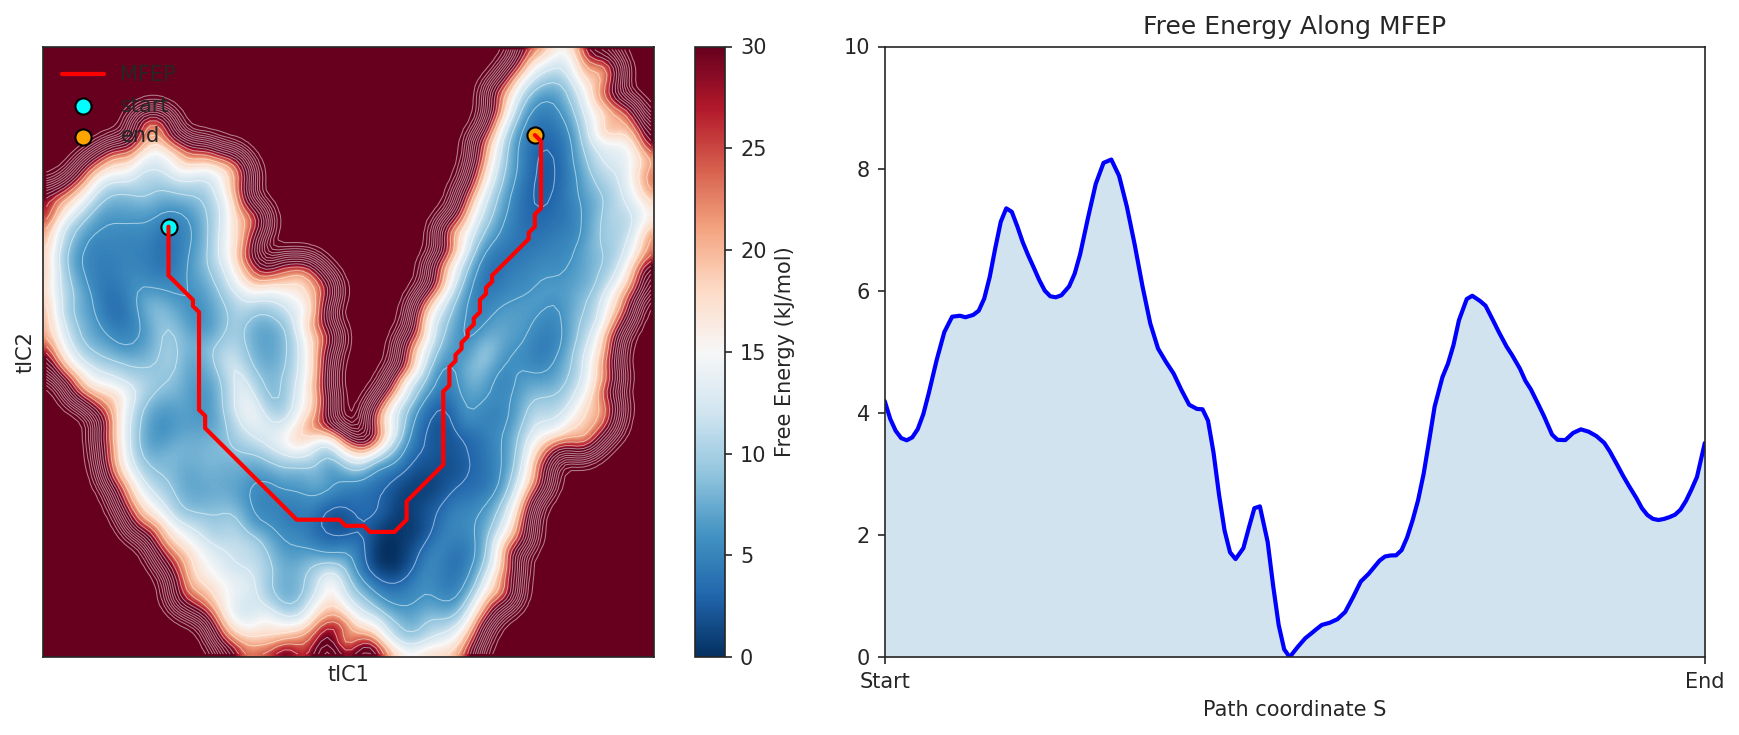

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.sparse import lil_matrix
from scipy.sparse.csgraph import dijkstra



def preprocess_fes(F, smooth_sigma=1.0):
    """
    平滑 + 平移到非负
    """
    F = np.array(F, dtype=float)

    finite_mask = np.isfinite(F)
    max_finite = np.nanmax(F[finite_mask])

    F[~finite_mask] = max_finite + 100.0

    if smooth_sigma > 0:
        F = gaussian_filter(F, sigma=smooth_sigma)

    # shift to non-negative
    F -= np.min(F)

    return F


def idx(i, j, ny):
    return i * ny + j


def inv_idx(k, ny):
    return k // ny, k % ny


def build_graph(F):
    nx, ny = F.shape
    n = nx * ny

    G = lil_matrix((n, n))

    neighbors = [
        (-1, 0), (1, 0),
        (0, -1), (0, 1),
        (-1, -1), (-1, 1),
        (1, -1), (1, 1)
    ]

    for i in range(nx):
        for j in range(ny):

            a = idx(i, j, ny)

            for di, dj in neighbors:
                ni, nj = i + di, j + dj

                if 0 <= ni < nx and 0 <= nj < ny:

                    b = idx(ni, nj, ny)

                    dist = np.sqrt(di**2 + dj**2)

                    weight = 0.5 * (F[i, j] + F[ni, nj]) * dist

                    G[a, b] = weight

    return G.tocsr()

def shortest_path_fes(F, start, end):
    nx, ny = F.shape

    G = build_graph(F)

    s = idx(*start, ny)
    t = idx(*end, ny)

    dist, pred = dijkstra(
        G,
        directed=False,
        indices=s,
        return_predecessors=True
    )

    if pred[t] == -9999:
        raise RuntimeError("No path found")

    path = []
    cur = t

    while cur != s:
        path.append(inv_idx(cur, ny))
        cur = pred[cur]

    path.append(start)
    path.reverse()

    return path

def project_along_path(F, path):


    path = np.array(path)

    ds = np.sqrt(np.sum(np.diff(path, axis=0)**2, axis=1))
    s = np.concatenate([[0], np.cumsum(ds)])

    fp = np.array([F[i, j] for i, j in path])
    fp = fp-np.min(fp)
    return s, fp




def plot_fes_and_profile(F, path, s=None, fp=None, levels=20):
    """
    F   : 2D free energy
    path: MFEP (i,j)
    s   : arc length (optional)
    fp  : free energy along path (optional)
    """

    # =========================
    # 0. shift to zero
    # =========================
    Fp = F - np.min(F)

    path = np.array(path)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

    # ============================================================
    # LEFT: 2D FES + PATH
    # ============================================================
    ax = axes[0]

    im = ax.imshow(
        Fp.T,
        origin="lower",
        cmap="RdBu_r",
        interpolation="bilinear",
        aspect="equal",
        vmax=30
    )

    # contour overlay
    nx, ny = F.shape
    X, Y = np.meshgrid(np.arange(nx), np.arange(ny), indexing="ij")

    ax.contour(
        X.T,
        Y.T,
        Fp.T,
        levels=levels,
        colors="white",
        linewidths=0.5,
        alpha=0.5
    )

    # MFEP path
    ax.plot(
        path[:, 0],
        path[:, 1],
        "r-",
        lw=2,
        label="MFEP"
    )

    ax.scatter(path[0, 0], path[0, 1], c="cyan", s=60, edgecolor="k",label='start')
    ax.scatter(path[-1, 0], path[-1, 1], c="orange", s=60, edgecolor="k",label='end')

    # ax.set_title("2D Free Energy Surface")
    ax.set_xlabel("tIC1")
    ax.set_ylabel("tIC2")
    ax.set_xticks([])
    ax.set_yticks([])
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Free Energy (kJ/mol)")

    ax.legend(frameon=False)

    # ============================================================
    # RIGHT: 1D PROFILE ALONG PATH
    # ============================================================
    ax = axes[1]

    if s is None or fp is None:
        ds = np.sqrt(np.sum(np.diff(path, axis=0)**2, axis=1))
        s = np.concatenate([[0], np.cumsum(ds)])

        fp = np.array([Fp[i, j] for i, j in path])

    ax.plot(s, fp, "b-", lw=2)

    ax.fill_between(s, fp, alpha=0.2)
    ax.set_ylim(0,10)

    ax.set_xticks([min(s), max(s)])
    ax.set_xticklabels(["Start", "End"])
    # ax.set_yticks([])
    ax.set_title("Free Energy Along MFEP")
    ax.set_xlabel("Path coordinate S")
    ax.set_xlim(min(s), max(s))

    plt.tight_layout()
    plt.savefig("MFEP_FES_and_Profile.pdf", transparent=True, bbox_inches='tight', dpi=300)
    plt.show()
def compute_mfep(
    F,
    start,
    end,
    smooth_sigma=1.0
):
    """
    Parameters
    ----------
    F : 2D ndarray
    start : (i,j)
    end   : (i,j)

    Returns
    -------
    path
    s
    fp
    """

    Fp = preprocess_fes(F, smooth_sigma)

    path = shortest_path_fes(Fp, start, end)

    s, fp = project_along_path(Fp, path)

    plot_fes_and_profile(Fp, path, s, fp)

    return path, s, fp

def cv_to_index(pos, ranges, F):
    """
    pos: (c1, c2)
    ranges: [(c1_min, c1_max), (c2_min, c2_max)]
    F: 2D free energy grid
    """

    c1, c2 = pos
    (c1_min, c1_max), (c2_min, c2_max) = ranges

    nx, ny = F.shape

    # normalize to [0, 1]
    x = (c1 - c1_min) / (c1_max - c1_min)
    y = (c2 - c2_min) / (c2_max - c2_min)

    # map to grid index
    i = int(np.round(x * (nx - 1)))
    j = int(np.round(y * (ny - 1)))

    # safety clipping
    i = np.clip(i, 0, nx - 1)
    j = np.clip(j, 0, ny - 1)

    return (i, j)

path, s, fp = compute_mfep(
    Z_2D.T,
    start=(20, 70),
    end=(80,85),
    smooth_sigma=1.0
)
np.save('s.npy', s)
np.save('fp.npy', fp)

In [47]:
np.save('tica_valid_clean.npy', tica_valid_clean)
np.save('wi_valid_clean.npy', wi_valid_clean)
np.save('pcca_assignment.npy', pcca.assignments)
np.save('stat_dist.npy', msm.stationary_distribution)
np.save('pcca_population.npy', pcca.coarse_grained_stationary_probability)
np.save('mfpt_ms.npy', mfpt_ms)
np.save('flux_ms.npy', flux_ms)
np.save('c_centers.npy', c_centers)
np.save('cryo_EM_apo.npy', cryo_EM_apo)
np.save('cryo_EM_bound.npy', cryo_EM_bound)

/tmp/ipykernel_4964/224274378.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(pcca_cmap)
/tmp/ipykernel_4964/224274378.py:110: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


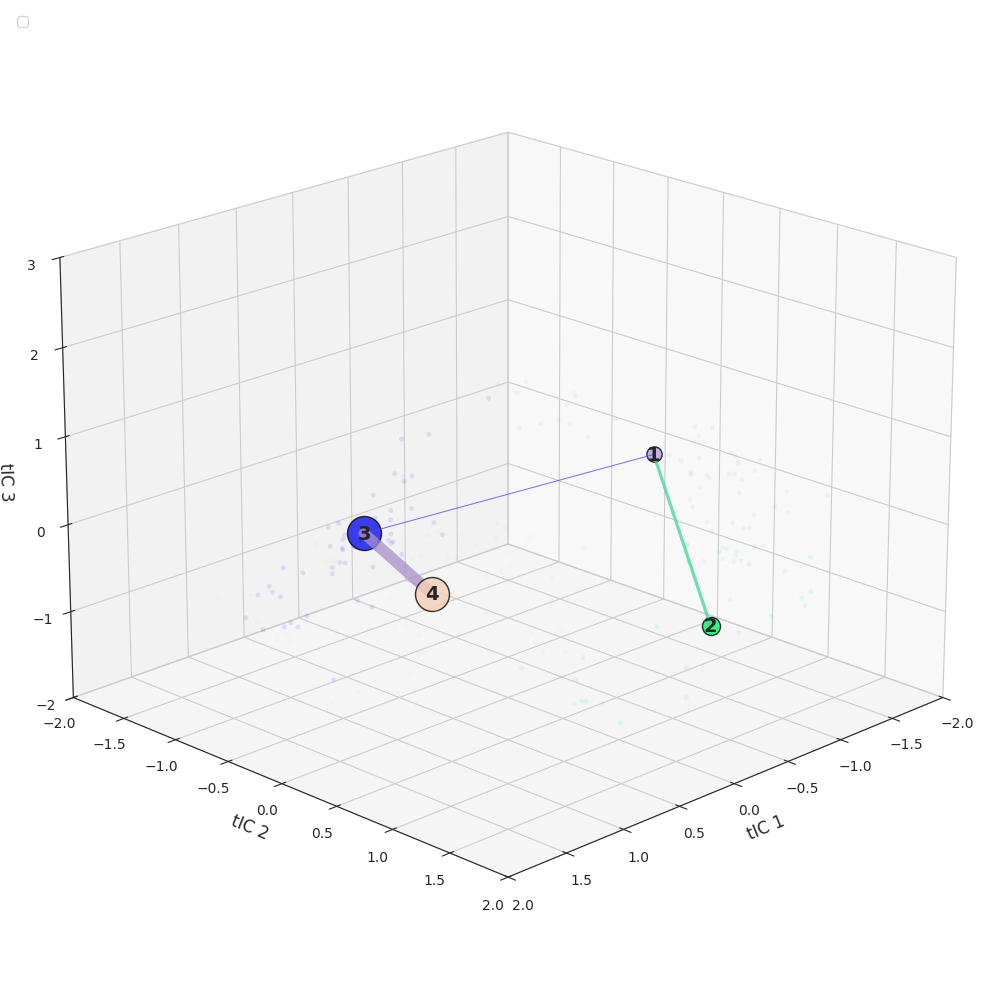

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

def plot_pcca_graph_3d(traj_all, traj_weights,  
                       c_centers, mfpt_matrix, flux_matrix, pcca_assignment, stat_dist, pcca_population,
                       dim_1=0, dim_2=1, dim_3=2,
                       c_centers_s=20, c_centers_marker='.', c_centers_a=0.2, 
                       pcca_cmap='gist_rainbow', c_edgecolor='none', linewidth=0.5, 
                       g_alpha=0.8, node_scale=500, edge_scale=5,
                       cryo_EM_apo=None, cryo_EM_bound=None, 
                       cryo_EM_marker='X', cryo_EM_s=150,
                       savedir=None, state=True, microstate=True, macrostate=True):

    n_states = len(np.unique(pcca_assignment))

    cmap = cm.get_cmap(pcca_cmap)
    # colours = [cmap(i/(n_states-1)) if n_states > 1 else cmap(0.5) for i in range(n_states)]
    colours = [
    "#B8A1E3",  # light lavender
    "#00F56A",  # mint-teal
    "#0D11F0" , # muted coral
    "#F4CFB6",  # apricot
        ]
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    macrostate_centroid = []
    for i in range(n_states):
        mask = pcca_assignment == i
        m_centers = c_centers[mask]
        m_weights = stat_dist[mask]

        weighted_centroid = np.average(m_centers, axis=0, weights=m_weights)
        macrostate_centroid.append(weighted_centroid)
    
    macrostate_centroid = np.array(macrostate_centroid)

    if state and microstate:
        for i in range(n_states):
            mask = pcca_assignment == i
            ax.scatter(c_centers[mask, dim_1], 
                       c_centers[mask, dim_2], 
                       c_centers[mask, dim_3],
                       s=c_centers_s, color=colours[i], marker=c_centers_marker, 
                       alpha=c_centers_a, edgecolor=c_edgecolor, linewidth=linewidth)

    if state and macrostate:

        cg_stationary_dist = np.array([sum(stat_dist[pcca_assignment == i]) for i in range(n_states)])

        node_sizes = pcca_population/pcca_population.max()*node_scale
        for i in range(n_states):
            ax.scatter(macrostate_centroid[i, dim_1], 
                       macrostate_centroid[i, dim_2], 
                       macrostate_centroid[i, dim_3],
                       s=node_sizes[i], color=colours[i], edgecolor='black', 
                       alpha=g_alpha, depthshade=True, zorder=10)
            

            ax.text(macrostate_centroid[i, dim_1], 
                    macrostate_centroid[i, dim_2], 
                    macrostate_centroid[i, dim_3], 
                    str(i+1), fontsize=14, fontweight='bold', ha='center', va='center', zorder=11)

        if flux_matrix is not None:
            max_flux = np.max(flux_matrix)
            for i in range(n_states):
                for j in range(n_states):
                    if i == j: continue
                    if flux_matrix[i, j] > 0:

                        w = (flux_matrix[i, j] / max_flux) * edge_scale
                        if w > 0.5: 
                            ax.plot([macrostate_centroid[i, dim_1], macrostate_centroid[j, dim_1]],
                                    [macrostate_centroid[i, dim_2], macrostate_centroid[j, dim_2]],
                                    [macrostate_centroid[i, dim_3], macrostate_centroid[j, dim_3]],
                                    color=colours[i], alpha=0.5, linewidth=w, zorder=5)
    if cryo_EM_apo is not None:
        ax.scatter(cryo_EM_apo[dim_1], cryo_EM_apo[dim_2], cryo_EM_apo[dim_3], 
                   s=cryo_EM_s, c='black', marker=cryo_EM_marker, label='Apo', depthshade=False)
    if cryo_EM_bound is not None:
        ax.scatter(cryo_EM_bound[dim_1], cryo_EM_bound[dim_2], cryo_EM_bound[dim_3], 
                   s=cryo_EM_s, c='red', marker=cryo_EM_marker, label='Bound', depthshade=False)

    ax.set_xlabel(f'tIC {dim_1+1}', fontsize=12)
    ax.set_ylabel(f'tIC {dim_2+1}', fontsize=12)
    ax.set_zlabel(f'tIC {dim_3+1}', fontsize=12)
    ax.set_zlim(-2,3)
    ax.set_xlim(-2,2)
    ax.set_ylim(-2,2)
    ax.view_init(elev=20, azim=45)
    
    plt.legend(loc='upper left')
    plt.tight_layout()
    
    if savedir:
        plt.savefig(savedir, dpi=300, bbox_inches='tight', transparent=False)
    plt.show()

    return None

tica2_valid = np.array(tica_output_concat[:, 2][valid_idx]).astype(np.float32)
nan_inf_mask2 = np.isnan(tica2_valid) | np.isinf(tica2_valid)
combined_mask_3d = ~(nan_inf_mask0 | nan_inf_mask1 | nan_inf_mask2)
tica_valid_clean_3d = np.vstack((
    tica0_valid[combined_mask_3d], 
    tica1_valid[combined_mask_3d], 
    tica2_valid[combined_mask_3d]
)).T
wi_valid_clean_3d = wi_valid[combined_mask_3d]


plot_pcca_graph_3d(
    traj_all=tica_valid_clean_3d,        
    traj_weights=wi_valid_clean_3d,      
    c_centers=c_centers,                 
    mfpt_matrix=mfpt_ms,                 
    flux_matrix=flux_ms,                 
    pcca_assignment=pcca.assignments,    
    stat_dist=msm.stationary_distribution, 
    pcca_population=pcca.coarse_grained_stationary_probability,
    dim_1=0, dim_2=1, dim_3=2,           
    c_centers_s=50,                      
    c_centers_a=0.1,                    
    pcca_cmap='jet',                     
    node_scale=600,                      
    edge_scale=8,                        
    cryo_EM_marker='*',
    savedir="PCCA_3D_Network1.pdf",  
    state=True, 
    microstate=True, 
    macrostate=True
)

In [ ]:
import subprocess


def save_PCCAstate_structures(pcca_assignments,assignments,macro_timeseries, round,n_frames,state_indices=None):
    macro_assignments = dict(enumerate(pcca_assignments))
    max_length = max(len(sublist) for sublist in assignments)
    macro_padding = np.array([ np.pad(np.vectorize(macro_assignments.get)(sublist),(0,max_length - len(sublist)),mode='constant',constant_values=-1) for sublist in assignments])
    conf_seed = []
    if state_indices is None:
        state_indices = np.unique(macro_timeseries) 
    for i,state_indice in enumerate(state_indices):
        conf_idx = np.array(np.where(macro_padding==state_indice)).T

        population_size = conf_idx.shape[0]
        actual_n_frames = min(n_frames, population_size) 
    
        if population_size == 0:
            continue
        conf_seed_frame = conf_idx[np.random.choice(conf_idx.shape[0], size=actual_n_frames,replace=False), :]
        conf_seed.append(conf_seed_frame)
    # # Create output directory if it doesn't exist
    output_dir = f'PCCA'
    if not os.path.exists(output_dir):
        os.mkdir(output_dir)
    # Save structures for each state
    for i, state in enumerate(conf_seed):
            for j, frame in enumerate(state):
                state_indice = state_indices[i]
                output_file = f"{output_dir}/state{state_indice}_seed{j}.pdb"
                xtc = frame[0]  
                cmd = f"echo 0 | gmx trjconv -f traj/traj{xtc}.xtc -s seed_round1/4/md.tpr -b {max(0,(frame[1])*1000)} -e {max(10,(frame[1])*1000 + 10)} -o {output_file}"
                
                try:
                    subprocess.run(cmd, shell=True, 
                                stdout=subprocess.DEVNULL, 
                                stderr=subprocess.DEVNULL, 
                                check=True)
                    print(f"Saved representative structure for seed {state_indice} to {output_file}")
                except subprocess.CalledProcessError:
                    print(f"Error: GMX failed for state {state_indice}, frame {j}")
              
                with open(f'{output_dir}/state_idx.txt','a') as f:
                        f.writelines(f'state {state_indice}: traj_idx {xtc} frame_idx {max(0,(frame[1])*1000)} \n')
    os.system(f"rm -rf {output_dir}/\#*")
    return macro_padding,conf_seed
def save_pseudotraj_structures(assignments,round,pseudo_trajectory):
    max_length = max(len(sublist) for sublist in assignments)
    assignments_padding = np.array([ np.pad(sublist,(0,max_length - len(sublist)),mode='constant',constant_values=-1) for sublist in assignments])
    conf_seed = []
    for i,seed in enumerate(pseudo_trajectory):
        conf_idx = np.array(np.where(assignments_padding==seed)).T
        # print(conf_idx)
        conf_seed_frame = conf_idx[np.random.randint(conf_idx.shape[0], size=1), :][0]
        conf_seed.append(conf_seed_frame)
    # Create output directory if it doesn't exist
    output_dir = f'pseudo_traj'
    if not os.path.exists(output_dir):
        os.mkdir(output_dir)
    # Save structures for each state
    for i, frame in enumerate(conf_seed):
            output_file = f"{output_dir}/seed{i}.gro"
            xtc = frame[0]  

            os.system(f"echo 0 | gmx trjconv -f traj/traj{xtc}.xtc -s seed_round1/4/md.tpr -b {max(0,(frame[1])*1000)} -e {max(10,(frame[1])*1000 + 10)} -o {output_file}")            
            print(f"Saved representative structure for seed {i} to {output_file}")
    
            with open(f'{output_dir}/seed_idx.txt','a') as f:
                    f.writelines(f'seed {i}: traj_idx {xtc} frame_idx {max(0,(frame[1])*1000)} \n')
    os.system(f"rm -rf {output_dir}/\#*")
    return conf_seed

In [ ]:
macro_padding,PCCA_conf_seed = save_PCCAstate_structures(pcca_assignments,assignments1,macro_timeseries,round,n_frames=1000)

Error: GMX failed for state 0, frame 0


In [ ]:
def dump_colvar_PCCA_states(data,pcca_assignments,assignments,macro_timeseries, round, arg_string, state_indices=None):
    arg_string = ['time'] + arg_string
    macro_assignments = dict(enumerate(pcca_assignments))
    max_length = max(len(sublist) for sublist in assignments)
    macro_padding = np.array([ np.pad(np.vectorize(macro_assignments.get)(sublist),(0,max_length - len(sublist)),mode='constant',constant_values=-1) for sublist in assignments])
    conf_seed = []
    if state_indices is None:
        state_indices = np.unique(macro_timeseries) 
    for i,state_indice in enumerate(state_indices):
        conf_idx = np.array(np.where(macro_padding==state_indice)).T
        conf_seed_frame = conf_idx
        conf_seed.append(conf_seed_frame)
    all_dats = []
    for i, state in enumerate(conf_seed):
        dats = []
        for j, frame in enumerate(state):
            dat = data[frame[0]][frame[1],:]
            dats.append(dat)
        dats = np.array(dats)
        n = dats.shape[0]
        index_col = np.arange(1, n + 1).reshape(-1, 1)
        dats = np.hstack((index_col, dats))
        all_dats.append(dats)
        with open(f'PCCA/COLVAR_{i}','w') as f:
            f.writelines(f"#! FIELDS {' '.join(arg_string)}\n")
            for arg in arg_string[1:]:
                f.writelines(f"#! SET min_{arg} -pi\n")
                f.writelines(f"#! SET max_{arg} pi\n")
            np.savetxt(f, dats, fmt='%.6f')
    return macro_padding,conf_seed,all_dats

In [ ]:
traj = plumed.read_as_pandas('traj/COLVAR0')
columns = list(traj.columns)
columns.remove('time')
arg_string = []
for i in range(len(columns)):
    if columns[i][2:5] == 'phi' or columns[i][2:5] == 'psi' or columns[i][2:5] == 'chi' or columns[i][2:7] == 'omega':
        arg_string.append(columns[i])

data = []
for i in range(142):
    traj = plumed.read_as_pandas(f'traj/COLVAR{i}')
    dat = traj[arg_string].to_numpy(dtype='float32')[500:]
    data.append(dat)
_, _, all_dats = dump_colvar_PCCA_states(data,pcca_assignments,assignments,macro_timeseries, round, arg_string, state_indices=[0,1])